## Climate stripe plots

Climate stripes (also known as "warming stripes") were popularised by
climate scientist Ed Hawkins.  Each stripe represents one year, coloured
by how much warmer or cooler it was relative to a baseline climatology.
The result is a striking, minimal visualisation of long-term temperature
change that needs no axes or numbers to communicate its message.

This notebook builds a climate stripe plot for ERA5 2-metre temperature
at London using two earthkit packages working together:

- **`earthkit-transforms`** computes the annual anomaly in a single call,
  handling all the temporal aggregation and baseline subtraction
- **`earthkit-plots`** renders the stripes and decorates the chart

The key insight is that both steps reduce to a *one-liner each* — the
complexity of computing an 85-year anomaly time series and rendering it
as a publication-quality chart is fully absorbed by the libraries.

### Imports

Three packages are needed:

- **`earthkit.data`** to fetch ERA5 data from the Copernicus Climate Data Store
- **`earthkit.transforms`** for the annual anomaly calculation
- **`earthkit.plots`** for the chart

`xr.set_options(keep_attrs=True)` ensures that CF metadata — variable
name, units, latitude, longitude — survives every `earthkit-transforms`
operation.  earthkit-plots reads these attributes to auto-label axes and
format title strings, so this line must come before any data loading.

In [1]:
import earthkit.data as ekd
import earthkit.plots as ekp
import earthkit.transforms as ekt
import xarray as xr

xr.set_options(keep_attrs=True)

### Fetching an 85-year ERA5 time series

We request hourly 2-metre temperature at a single point — Reading, UK
(51.5°N, 1°W) — from 1940 to the present.  The `reanalysis-era5-single-levels-timeseries`
dataset returns a cloud-optimised Zarr archive, so the download is fast
even though the time series spans 85 years.

The long date range is what makes climate stripes meaningful: a warming
trend that is invisible over a decade becomes unmistakable over eight.

In [2]:
# dataset = "reanalysis-era5-single-levels-timeseries"
# request = {
#     "variable": "2m_temperature",
#     "location": {"longitude": -1, "latitude": 51.5},
#     "date": ["1940-01-01/2025-12-31"],
#     "data_format": "netcdf",
# }

# era5_hourly = ekd.from_source("cds", dataset, request).to_xarray()

era5_hourly = ekd.from_source("sample", "era5-reading-2m-temperature.nc")

era5_hourly

era5-reading-2m-temperature.nc:   0%|          | 0.00/8.64M [00:00<?, ?B/s]

path,/var/folders/vt/7j2c2tmx4m14gn_sg3zpf5l00000gn/T/tmprh56ozf9/url-d6d61f6deaa786ad1f8ef843bf0b36452a615d811ad8ada05887bd229cc128c4.nc
size,8.6 MiB
types,"xarray, pandas, fieldlist, numpy, array"


### Computing the annual anomaly

Climate stripes colour each year by its *anomaly* — how much warmer or
cooler it was compared to a chosen baseline period — not by its absolute
temperature.  Using anomalies removes the effect of seasonal cycles and
makes the long-term trend visible.

`ekt.climatology.auto_anomaly` does this in one call:

1. It aggregates the raw hourly data to annual means (`frequency="year"`)
2. It computes the climatological baseline mean over the specified
   `climatology_range` (1981–2010 is the WMO standard reference period)
3. It subtracts the baseline from every annual value to produce the
   anomaly time series

The output is a Dataset with a `valid_time` dimension of 86 annual values
(one per year 1940–2025), each carrying the departure from the 1981–2010
mean in the original units (Kelvin, which is equivalent to °C for
differences).

In [3]:
anomaly = ekt.climatology.auto_anomaly(
    era5_hourly,
    frequency="year",
    climatology_range=("1981", "2010"),
)
anomaly

<xarray.Dataset> Size: 1kB
Dimensions:     (valid_time: 86)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 688B 1940-12-31 ... 2025-12-31
    latitude    float64 8B 51.5
    longitude   float64 8B -1.0
Data variables:
    t2m         (valid_time) float32 344B -0.6879 -0.8204 -1.216 ... 1.114 1.333
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2024-09-02T04:48 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

### Plotting the stripes

`ekp.timeseries.stripes` maps each annual anomaly value to a colour and
draws it as a filled vertical stripe.  The key arguments:

- **`cmap="RdBu_r"`** — the diverging red-blue palette, reversed so that
  blue = cool and red = warm, matching Ed Hawkins' original design
- **`.xticks(frequency="5Y")`** — one tick every 5 years, keeping the
  x-axis readable without cluttering the minimal chart
- **`.title(...)`** — format-string placeholders (`{variable_name}`,
  `{latitude:%Lt}`, etc.) are filled in from the data's CF attributes at
  render time

The chart deliberately has no y-axis — the colour encodes all the
information, and gridlines would distract from the visual message.

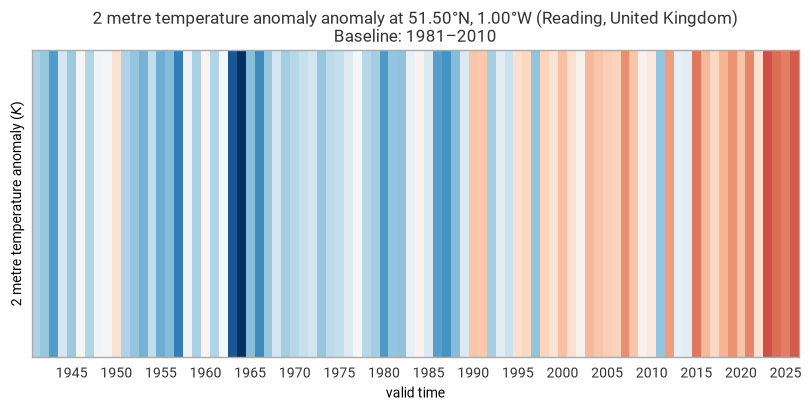

In [4]:
(
    ekp.timeseries.stripes(anomaly, cmap="RdBu_r")
    .xticks(frequency="5Y")
    .title(
        "{variable_name} anomaly at {latitude:%Lt}, {longitude:%Ln} "
        "({location:%c}, {location:%C})\n"
        "Baseline: 1981–2010"
    )
    .show()
)

### What the chart shows

Each stripe is one year.  Blues indicate years cooler than the 1981–2010
average; reds indicate warmer years.  The colour intensity reflects the
size of the anomaly: a deep red stripe means that year was substantially
warmer than the baseline.

The shift from predominantly blue in the early decades to predominantly
red in recent years is the signature of long-term warming — the same
signal that appears in every global and regional temperature record.